In [1]:
import numpy as np
import pandas as pd

In [2]:
alpha_fold0 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/ctcf_elimination/fold0_alphagenome_results.tsv", sep="\t")

alpha_fold0["fold"] = [0 for i in range(len(alpha_fold0))]

In [3]:
alpha_fold1 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/ctcf_elimination/fold1_alphagenome_results.tsv", sep="\t")

alpha_fold1["fold"] = [1 for i in range(len(alpha_fold1))]

In [4]:
alpha_fold2 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/ctcf_elimination/fold2_alphagenome_results.tsv", sep="\t")

alpha_fold2["fold"] = [2 for i in range(len(alpha_fold2))]

In [5]:
alpha_df = pd.concat([alpha_fold0, alpha_fold1, alpha_fold2], ignore_index=True)

In [7]:
alpha_df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'URQ_result', 'URQ_target', 'URQ_init', 'num_edits', 'GC_seq',
       'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'alpha_og_urq',
       'alpha_ed_urq', 'alpha_urq_diff'],
      dtype='object')

In [8]:
alpha_df["URQ_diff"] = alpha_df["URQ_result"] - alpha_df["URQ_init"]

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

Pearson R = 0.7853, p-value = 1.4856e-35


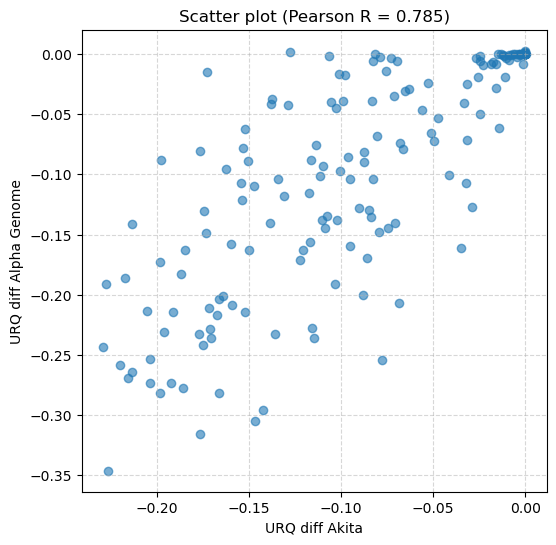

In [10]:
# Assuming df and alpha_df have the same row order
x = alpha_df["URQ_diff"].values
y = alpha_df["alpha_urq_diff"].values

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("URQ diff Akita")
plt.ylabel("URQ diff Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [12]:
alpha_df[alpha_df["CTCFs_num"] == 0]

,chrom,fold,PearsonR,centered_start,centered_end,centered_flat_start,centered_flat_end,active_fraction,neutral_fraction,repressive_fraction,...,init_CTCFs_num,CTCFs_num,FIMO_sum,FIMO_max,orientation,positions,alpha_og_urq,alpha_ed_urq,alpha_urq_diff,URQ_diff
1,chr11,0,0.746112,65677312,66988032,195,317,0.333333,0.533333,0.133333,...,1,0,0.0,0.0,no,(),0.316055,0.112811,-0.203244,-0.166539
3,chr3,0,0.672787,53286912,54597632,187,325,0.360000,0.520000,0.120000,...,1,0,0.0,0.0,no,(),0.187604,0.187226,-0.000378,-0.001517
4,chr3,0,0.676442,119885824,121196544,154,358,0.500000,0.500000,0.000000,...,1,0,0.0,0.0,no,(),0.112275,0.070694,-0.041582,-0.138215
5,chr3,0,0.681364,101859328,103170048,202,310,0.371429,0.514286,0.114286,...,0,0,0.0,0.0,no,(),0.185862,0.185504,-0.000359,-0.002556
7,chr3,0,0.690577,80795648,82106368,159,353,0.473684,0.526316,0.000000,...,0,0,0.0,0.0,no,(),0.342676,0.342387,-0.000289,-0.003039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,chr6,2,0.775228,95879168,97189888,159,353,0.444444,0.500000,0.055556,...,0,0,0.0,0.0,no,(),0.392250,0.229218,-0.163033,-0.120600
151,chr6,2,0.866654,99411968,100722688,201,311,0.250000,0.500000,0.250000,...,0,0,0.0,0.0,no,(),0.221915,0.220814,-0.001102,-0.011835
152,chr6,2,0.896686,116738048,118048768,175,337,0.441176,0.500000,0.058824,...,1,0,0.0,0.0,no,(),0.332365,0.101493,-0.230871,-0.196419
161,chr9,2,0.846394,112386048,113696768,187,325,0.444444,0.500000,0.055556,...,0,0,0.0,0.0,no,(),0.319162,0.226129,-0.093033,-0.109890


Pearson R = 0.7132, p-value = 4.4652e-15


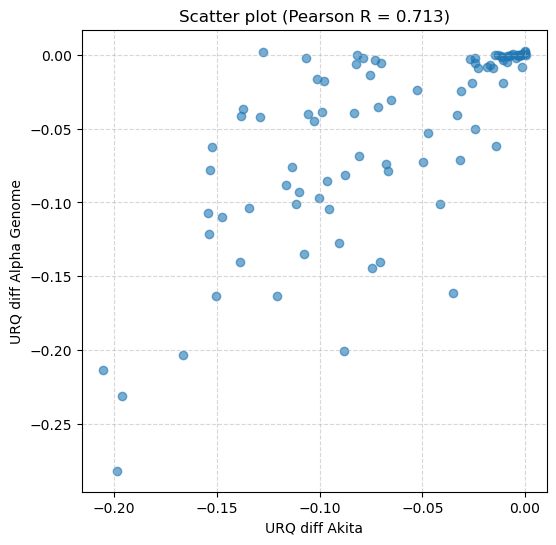

In [13]:
# Assuming df and alpha_df have the same row order
x = alpha_df[alpha_df["CTCFs_num"] == 0]["URQ_diff"].values
y = alpha_df[alpha_df["CTCFs_num"] == 0]["alpha_urq_diff"].values

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("URQ diff Akita")
plt.ylabel("URQ diff Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()